In [73]:
# import comet_ml at the top of your file
from comet_ml import Experiment

Instead of making our API key public, we will read it from a config file we created. For more information, follow this link: https://blog.netwrix.com/2022/11/14/how-to-hide-api-keys-github/


In [75]:
# From https://blog.netwrix.com/2022/11/14/how-to-hide-api-keys-github/
import config
# Create an experiment with your api key
experiment = Experiment(
    api_key = config.api_key,
    project_name = config.project_name,
    workspace = config.workspace,
)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/khulu2/classification-predict/29f26024642140f0a22b6c056aaca791



## Import the important libraries

In [76]:
import pandas as pd
import numpy as np
import re
from tqdm.auto import tqdm
import itertools

# imports for data visualisation
import seaborn as sns
from PIL import Image
from scipy import stats
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
from wordcloud import WordCloud, ImageColorGenerator
%matplotlib inline

# imports for pre-processing
import os
from nltk.tokenize import WordPunctTokenizer
from bs4 import BeautifulSoup
from collections import Counter
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tokenize import TweetTokenizer
from nltk.stem.porter import *
import string
import nltk

#
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# classification models
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# feature extraction
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# metrics
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from scikitplot.metrics import plot_roc, plot_confusion_matrix # pip install scikit-plot

## Read in the data

In [77]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test_with_no_labels.csv")

# Create copies for modeling
train = df_train.copy()
test = df_test.copy()

In [78]:
df_train.head()

,sentiment,message,tweetid
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221
1,1,It's not like we lack evidence of anthropogeni...,126103
2,2,RT @RawStory: Researchers say we have three ye...,698562
3,1,#TodayinMaker# WIRED : 2016 was a pivotal year...,573736
4,1,"RT @SoyNovioDeTodas: It's 2016, and a racist, ...",466954


In [79]:
df_test.head()

,message,tweetid
0,Europe will now be looking to China to make su...,169760
1,Combine this with the polling of staffers re c...,35326
2,"The scary, unimpeachable evidence that climate...",224985
3,@Karoli @morgfair @OsborneInk @dailykos \r\nPu...,476263
4,RT @FakeWillMoore: 'Female orgasms cause globa...,872928


In [80]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15819 entries, 0 to 15818
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  15819 non-null  int64 
 1   message    15819 non-null  object
 2   tweetid    15819 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 370.9+ KB


Checking if there are missing values...


In [81]:
df_train.isna().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15819 entries, 0 to 15818
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sentiment  15819 non-null  bool 
 1   message    15819 non-null  bool 
 2   tweetid    15819 non-null  bool 
dtypes: bool(3)
memory usage: 46.5 KB


In [82]:
df_train.isnull().sum()

sentiment    0
message      0
tweetid      0
dtype: int64

There are no missing values in the train dataset.

## Pre-processing

First, we extract mentions and hashtags

In [83]:
def get_hashtags_and_mentions(df):
    df["hashtags"] = df["message"].str.lower().str.findall(r'#.*?(?=\s|$)')
    hashtags = df["hashtags"]
    
    df["mentions"] = df["message"].str.lower().str.findall(r'@\w*')
    mentions = df["mentions"]
    
    df["url"] = df["message"].str.lower().str.findall(r'http\S+|www.\S+')
    urls = df["url"]

    df["hashtags"] = [np.nan if len(x) == 0 else x for x in hashtags]
    df["mentions"] = [np.nan if len(x) == 0 else x for x in mentions]
    df["url"] = [np.nan if len(x) == 0 else x for x in urls]
    
    return df

In [84]:
get_hashtags_and_mentions(df_train).head()

,sentiment,message,tweetid,hashtags,mentions,url
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc]
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN
2,2,RT @RawStory: Researchers say we have three ye...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]"
3,1,#TodayinMaker# WIRED : 2016 was a pivotal year...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd]
4,1,"RT @SoyNovioDeTodas: It's 2016, and a racist, ...",466954,[#electionnight],[@soynoviodetodas],NaN


We apply each step we applied to the training dataset to the test dataset too.

In [85]:
get_hashtags_and_mentions(df_test).head()

,message,tweetid,hashtags,mentions,url
0,Europe will now be looking to China to make su...,169760,NaN,NaN,[https://t.co/o7t8rcgwdq]
1,Combine this with the polling of staffers re c...,35326,NaN,NaN,[https://t.co/ifrm7eexpj]
2,"The scary, unimpeachable evidence that climate...",224985,"[#itstimetochange, #climatechange]",[@zeroco2_],[https://t.co/yaedqcv9ki]
3,@Karoli @morgfair @OsborneInk @dailykos \r\nPu...,476263,NaN,"[@karoli, @morgfair, @osborneink, @dailykos]",NaN
4,RT @FakeWillMoore: 'Female orgasms cause globa...,872928,NaN,[@fakewillmoore],NaN


Second, we remove Twitter handles (e.g., @RawStory), hashtags, mentions and urls. These do not provide any important information related to our objective

In [86]:
def remove_urls(text):
    return re.sub(r'http\S+|www.\S+', '', text)

def remove_twitter_handles(text):
    return re.sub(r'@\w*', '', text)

def remove_hashtags(text):
    return re.sub(r'#.*?(?=\s|$)', '', text)

def remove_rt(text):
    return text.replace('RT', '')

df_train["message"] = df_train["message"].apply(remove_urls)
df_train["message"] = df_train["message"].apply(remove_twitter_handles)
df_train["message"] = df_train["message"].apply(remove_hashtags)
df_train["message"] = df_train["message"].apply(remove_rt)

df_train.head()

,sentiment,message,tweetid,hashtags,mentions,url
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc]
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]"
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd]
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN


In [87]:
df_test["message"] = df_test["message"].apply(remove_urls)
df_test["message"] = df_test["message"].apply(remove_twitter_handles)
df_test["message"] = df_test["message"].apply(remove_hashtags)
df_test["message"] = df_test["message"].apply(remove_rt)

df_test.head()

,message,tweetid,hashtags,mentions,url
0,Europe will now be looking to China to make su...,169760,NaN,NaN,[https://t.co/o7t8rcgwdq]
1,Combine this with the polling of staffers re c...,35326,NaN,NaN,[https://t.co/ifrm7eexpj]
2,"The scary, unimpeachable evidence that climate...",224985,"[#itstimetochange, #climatechange]",[@zeroco2_],[https://t.co/yaedqcv9ki]
3,\r\nPutin got to you too Jill ! \r\nTrump ...,476263,NaN,"[@karoli, @morgfair, @osborneink, @dailykos]",NaN
4,: 'Female orgasms cause global warming!'\r\n-...,872928,NaN,[@fakewillmoore],NaN


## Tokenization

Tokenization is the process of tokenizing or splitting a string, text into a list of tokens. One can think of token as parts like a word is a token in a sentence, and a sentence is a token in a paragraph.
Now we will tokenize all the cleaned tweets in our dataset. Tokens are individual terms or words, and tokenization is the process of splitting a string of text into tokens.

During tokenization, we will also remove the following:
- Punctuation, special characters and numbers: With regards to punctuation, special characters and numbers, many, if not all, do not change or determine the overall sentiment of a tweet. Thus, it is important to remove these from the tweets.

- Short words (i.e., single letters): A vast majoity of short words which are only one letter long do not add much information surrounding the sentiment.

In [88]:
def tokenize_tweets(df):
    # tokenizing the tweets
    # Read more: https://www.kaggle.com/general/288653
    cleaned_tweets = df["message"].apply(TweetTokenizer().tokenize)

    # remove punctuation
    cleaned_tweets = cleaned_tweets.apply(lambda x : [token for token in x if token not in string.punctuation])

    # removing digits from the tweets
    cleaned_tweets = cleaned_tweets.apply(lambda x: [token for token in x if token not in list(string.digits)])

    # removing all one character tokens
    cleaned_tweets = cleaned_tweets.apply(lambda x: [token for token in x if len(token) > 1])
    
    df["tokenized_tweets"] = cleaned_tweets
    
    return df["tokenized_tweets"]

In [89]:
tokenize_tweets(df_train).head()

0    [PolySciMajor, EPA, chief, doesn't, think, car...
1    [It's, not, like, we, lack, evidence, of, anth...
2    [Researchers, say, we, have, three, years, to,...
3    [WIRED, 2016, was, pivotal, year, in, the, war...
4    [It's, 2016, and, racist, sexist, climate, cha...
Name: tokenized_tweets, dtype: object

In [90]:
tokenize_tweets(df_test).head()

0    [Europe, will, now, be, looking, to, China, to...
1    [Combine, this, with, the, polling, of, staffe...
2    [The, scary, unimpeachable, evidence, that, cl...
3    [Putin, got, to, you, too, Jill, Trump, doesn'...
4    [Female, orgasms, cause, global, warming, Sarc...
Name: tokenized_tweets, dtype: object

Stop words are commonly occurring words that are often considered to be insignificant and are typically removed from text during preprocessing. These words include articles (e.g., "a," "an," "the"), prepositions (e.g., "in," "on," "at"), conjunctions (e.g., "and," "but," "or"), and other high-frequency words that do not carry substantial meaning or contribute significantly to the context of the text.

The rationale behind removing stop words is to reduce the dimensionality of the data and eliminate noise that may interfere with certain NLP tasks, such as text classification, information retrieval, and sentiment analysis. By removing these frequently occurring words, we can focus on the more informative and content-rich words that are likely to carry more significance in the analysis.

In [91]:
nltk.download('stopwords')

stop = stopwords.words('english')

# Convert to lower case
df_train["tokenized_tweets"] = df_train["tokenized_tweets"].apply(lambda x: [word.lower() for word in x])

# Remove stopwords
df_train["no_stopwords"] = df_train["tokenized_tweets"].apply(lambda x: [item for item in x if item not in stop])

df_train.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,sentiment,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc],"[polyscimajor, epa, chief, doesn't, think, car...","[polyscimajor, epa, chief, think, carbon, diox..."
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN,"[it's, not, like, we, lack, evidence, of, anth...","[like, lack, evidence, anthropogenic, global, ..."
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]","[researchers, say, we, have, three, years, to,...","[researchers, say, three, years, act, climate,..."
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd],"[wired, 2016, was, pivotal, year, in, the, war...","[wired, 2016, pivotal, year, war, climate, cha..."
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN,"[it's, 2016, and, racist, sexist, climate, cha...","[2016, racist, sexist, climate, change, denyin..."


In [92]:
# do to test what we do to train
df_test["tokenized_tweets"] = df_test["tokenized_tweets"].apply(lambda x: [word.lower() for word in x])

# Remove stopwords
df_test["no_stopwords"] = df_test["tokenized_tweets"].apply(lambda x: [item for item in x if item not in stop])

df_test.head()

,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords
0,Europe will now be looking to China to make su...,169760,NaN,NaN,[https://t.co/o7t8rcgwdq],"[europe, will, now, be, looking, to, china, to...","[europe, looking, china, make, sure, alone, fi..."
1,Combine this with the polling of staffers re c...,35326,NaN,NaN,[https://t.co/ifrm7eexpj],"[combine, this, with, the, polling, of, staffe...","[combine, polling, staffers, climate, change, ..."
2,"The scary, unimpeachable evidence that climate...",224985,"[#itstimetochange, #climatechange]",[@zeroco2_],[https://t.co/yaedqcv9ki],"[the, scary, unimpeachable, evidence, that, cl...","[scary, unimpeachable, evidence, climate, chan..."
3,\r\nPutin got to you too Jill ! \r\nTrump ...,476263,NaN,"[@karoli, @morgfair, @osborneink, @dailykos]",NaN,"[putin, got, to, you, too, jill, trump, doesn'...","[putin, got, jill, trump, believe, climate, ch..."
4,: 'Female orgasms cause global warming!'\r\n-...,872928,NaN,[@fakewillmoore],NaN,"[female, orgasms, cause, global, warming, sarc...","[female, orgasms, cause, global, warming, sarc..."


The words `climatechange`, `climate` and `change`, do not serve a purpose in this case since all tweets should have at least one of them. So we remove them

In [93]:
remove_words = ["climatechange", "climate", "change"]
df_train["no_climate"] = [[a for a in word if not a in remove_words] for word in df_train["no_stopwords"]]

df_train.head()

,sentiment,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords,no_climate
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc],"[polyscimajor, epa, chief, doesn't, think, car...","[polyscimajor, epa, chief, think, carbon, diox...","[polyscimajor, epa, chief, think, carbon, diox..."
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN,"[it's, not, like, we, lack, evidence, of, anth...","[like, lack, evidence, anthropogenic, global, ...","[like, lack, evidence, anthropogenic, global, ..."
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]","[researchers, say, we, have, three, years, to,...","[researchers, say, three, years, act, climate,...","[researchers, say, three, years, act, late]"
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd],"[wired, 2016, was, pivotal, year, in, the, war...","[wired, 2016, pivotal, year, war, climate, cha...","[wired, 2016, pivotal, year, war]"
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN,"[it's, 2016, and, racist, sexist, climate, cha...","[2016, racist, sexist, climate, change, denyin...","[2016, racist, sexist, denying, bigot, leading..."


In [94]:
df_test["no_climate"] = [[a for a in word if not a in remove_words] for word in df_test["no_stopwords"]]

df_test.head()

,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords,no_climate
0,Europe will now be looking to China to make su...,169760,NaN,NaN,[https://t.co/o7t8rcgwdq],"[europe, will, now, be, looking, to, china, to...","[europe, looking, china, make, sure, alone, fi...","[europe, looking, china, make, sure, alone, fi..."
1,Combine this with the polling of staffers re c...,35326,NaN,NaN,[https://t.co/ifrm7eexpj],"[combine, this, with, the, polling, of, staffe...","[combine, polling, staffers, climate, change, ...","[combine, polling, staffers, womens, rights, f..."
2,"The scary, unimpeachable evidence that climate...",224985,"[#itstimetochange, #climatechange]",[@zeroco2_],[https://t.co/yaedqcv9ki],"[the, scary, unimpeachable, evidence, that, cl...","[scary, unimpeachable, evidence, climate, chan...","[scary, unimpeachable, evidence, already, ..]"
3,\r\nPutin got to you too Jill ! \r\nTrump ...,476263,NaN,"[@karoli, @morgfair, @osborneink, @dailykos]",NaN,"[putin, got, to, you, too, jill, trump, doesn'...","[putin, got, jill, trump, believe, climate, ch...","[putin, got, jill, trump, believe, thinks, hoax]"
4,: 'Female orgasms cause global warming!'\r\n-...,872928,NaN,[@fakewillmoore],NaN,"[female, orgasms, cause, global, warming, sarc...","[female, orgasms, cause, global, warming, sarc...","[female, orgasms, cause, global, warming, sarc..."


Create a column for each tweets sentiment

In [95]:
df_train["sentiment_name"] = df_train["sentiment"].map({-1: "Anti", 0: "Neutral", 1: "Pro", 2: "News"})
df_train.head()

,sentiment,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords,no_climate,sentiment_name
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc],"[polyscimajor, epa, chief, doesn't, think, car...","[polyscimajor, epa, chief, think, carbon, diox...","[polyscimajor, epa, chief, think, carbon, diox...",Pro
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN,"[it's, not, like, we, lack, evidence, of, anth...","[like, lack, evidence, anthropogenic, global, ...","[like, lack, evidence, anthropogenic, global, ...",Pro
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]","[researchers, say, we, have, three, years, to,...","[researchers, say, three, years, act, climate,...","[researchers, say, three, years, act, late]",News
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd],"[wired, 2016, was, pivotal, year, in, the, war...","[wired, 2016, pivotal, year, war, climate, cha...","[wired, 2016, pivotal, year, war]",Pro
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN,"[it's, 2016, and, racist, sexist, climate, cha...","[2016, racist, sexist, climate, change, denyin...","[2016, racist, sexist, denying, bigot, leading...",Pro


In [96]:
df_eda = df_train.copy()
df_eda.head()

,sentiment,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords,no_climate,sentiment_name
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc],"[polyscimajor, epa, chief, doesn't, think, car...","[polyscimajor, epa, chief, think, carbon, diox...","[polyscimajor, epa, chief, think, carbon, diox...",Pro
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN,"[it's, not, like, we, lack, evidence, of, anth...","[like, lack, evidence, anthropogenic, global, ...","[like, lack, evidence, anthropogenic, global, ...",Pro
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]","[researchers, say, we, have, three, years, to,...","[researchers, say, three, years, act, climate,...","[researchers, say, three, years, act, late]",News
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd],"[wired, 2016, was, pivotal, year, in, the, war...","[wired, 2016, pivotal, year, war, climate, cha...","[wired, 2016, pivotal, year, war]",Pro
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN,"[it's, 2016, and, racist, sexist, climate, cha...","[2016, racist, sexist, climate, change, denyin...","[2016, racist, sexist, denying, bigot, leading...",Pro


# Exploratory data analysis

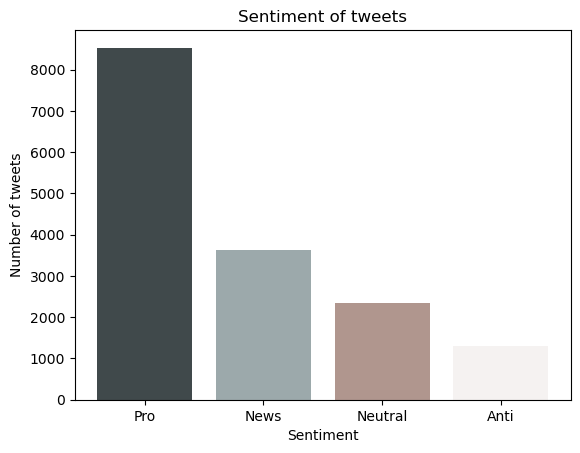

In [98]:
colors = ['#40494b', '#9ca9ab','#b0968e','#f5f2f1']  # Specify colors for each bar

plt.bar(df_eda['sentiment_name'].unique(), df_eda['sentiment_name'].value_counts(), color = colors)

# Add labels and title
plt.xlabel('Sentiment')
plt.ylabel('Number of tweets')
plt.title('Sentiment of tweets')

# Display the plot
plt.show()


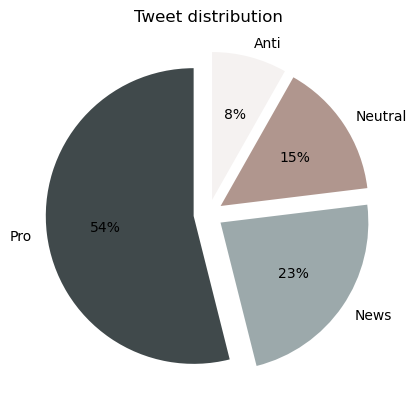

In [99]:
labels = df_eda['sentiment_name'].unique()

plt.pie(df_eda["sentiment_name"].value_counts(),
            labels=labels,
            autopct="%1.0f%%",
            startangle=90,
            colors = colors,
            explode=tuple([0.1] * len(labels)))

plt.title('Tweet distribution')

# Display the plot
plt.show()

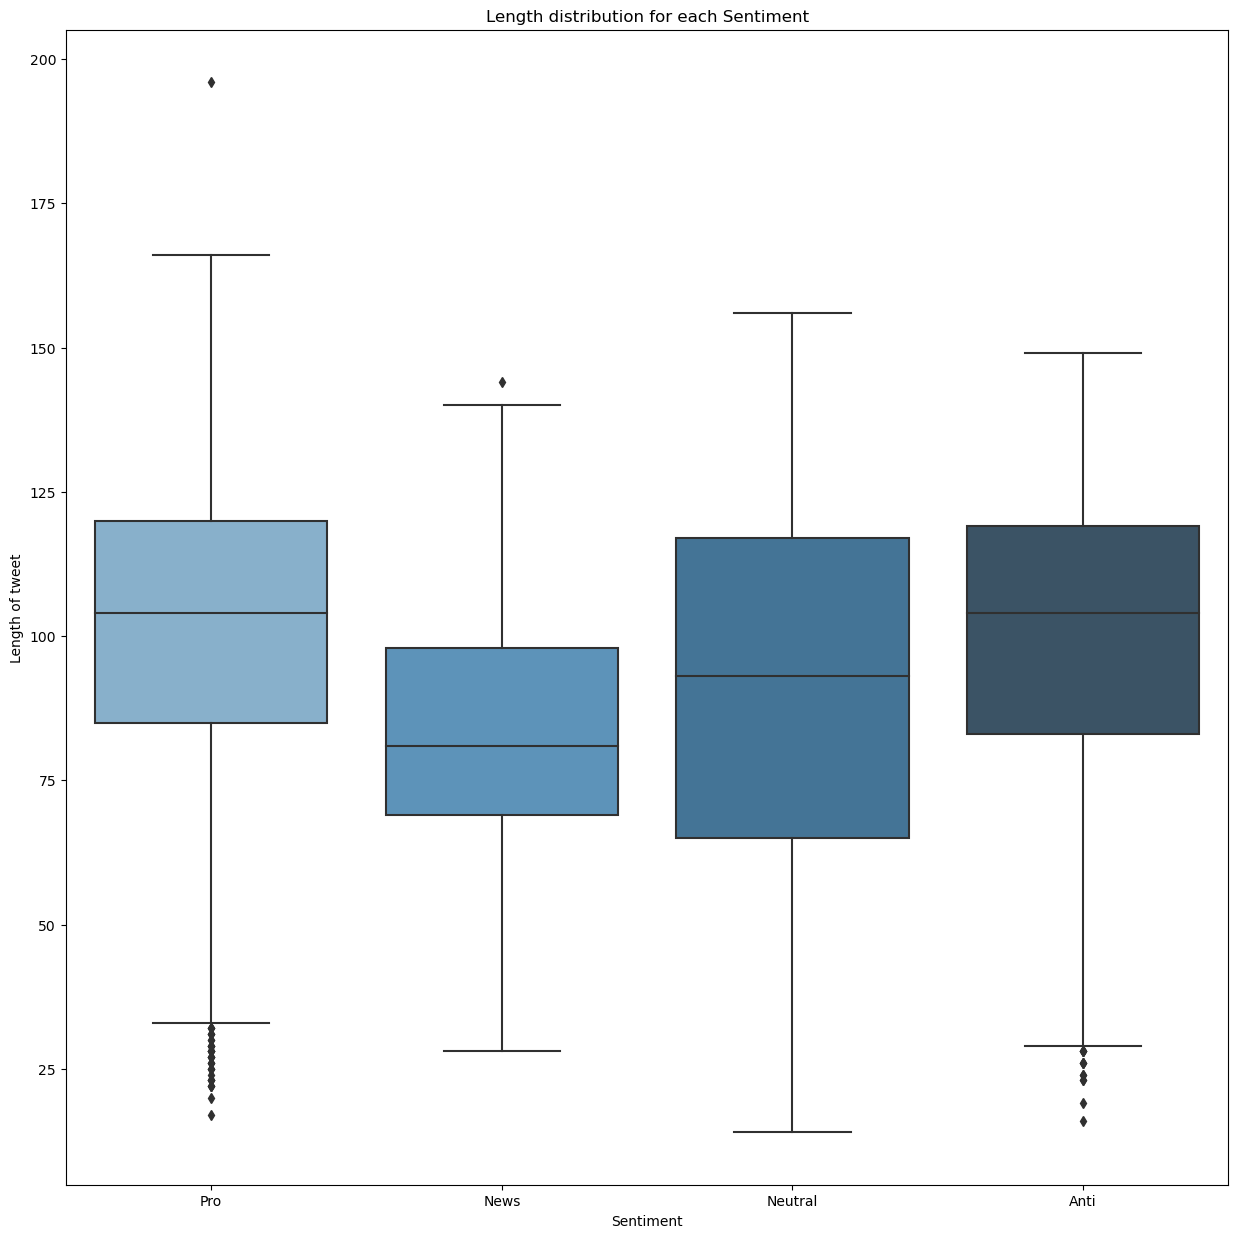

In [100]:
plt.figure(figsize=(15, 15))
sns.boxplot(x="sentiment_name", y=df_eda['message'].apply(len), data=df_eda, palette=("Blues_d"))
plt.title("Length distribution for each Sentiment")

# Adding labels 
plt.xlabel('Sentiment')
plt.ylabel('Length of tweet')

plt.show()

In [101]:
#Top 10 hashtags used in each class
top10 = {}

by_sentiment = df_eda.groupby("sentiment_name")
for sentiment, group in tqdm(by_sentiment):
    hashtags = group["hashtags"].apply(lambda tweet: [re.sub(r'\]', '', ht) for ht in re.findall(r'#\w+', str(tweet))])
    hashtags = itertools.chain(*hashtags)
    hashtags = [ht.lower() for ht in hashtags]
    
    frequency = nltk.FreqDist(hashtags)
    
    df_hashtags = pd.DataFrame({
        "hashtags": list(frequency.keys()),
        "count": list(frequency.values()),
    })
    top10_htags = df_hashtags.nlargest(10, columns=["count"])
    
    top10[sentiment] = top10_htags.reset_index(drop=True)

display(pd.concat(top10, axis=1).head(n=10))

100%|██████████| 4/4 [00:00<00:00, 106.37it/s]


Anti                Neutral                     News         
          hashtags count         hashtags count           hashtags count   
0            #maga    14         #climate    19           #climate   135  \
1         #climate    10   #climatechange    15     #climatechange    65   
2           #trump     8           #trump    12       #environment    47   
3   #climatechange     8  #beforetheflood     5              #news    32   
4   #globalwarming     5           #qanda     4             #trump    25   
5        #fakenews     4       #amreading     4           #science    18   
6    #opchemtrails     4           #cop22     4                #p2    14   
7            #tcot     4   #globalwarming     3  #greatbarrierreef    14   
8  #parisagreement     4     #parisaccord     3             #cop22    14   
9           #qanda     3   #climatecounts     3    #parisagreement     9   

                Pro        
           hashtags count  
0          #climate   188  
1   #beforetheflood   148  
2    #climatechange   120  
3  #imvotingbecause    62  
4            #cop22    59  
5   #parisagreement    52  
6     #actonclimate    49  
7            #trump    43  
8                #ã    37  
9    #globalwarming    35

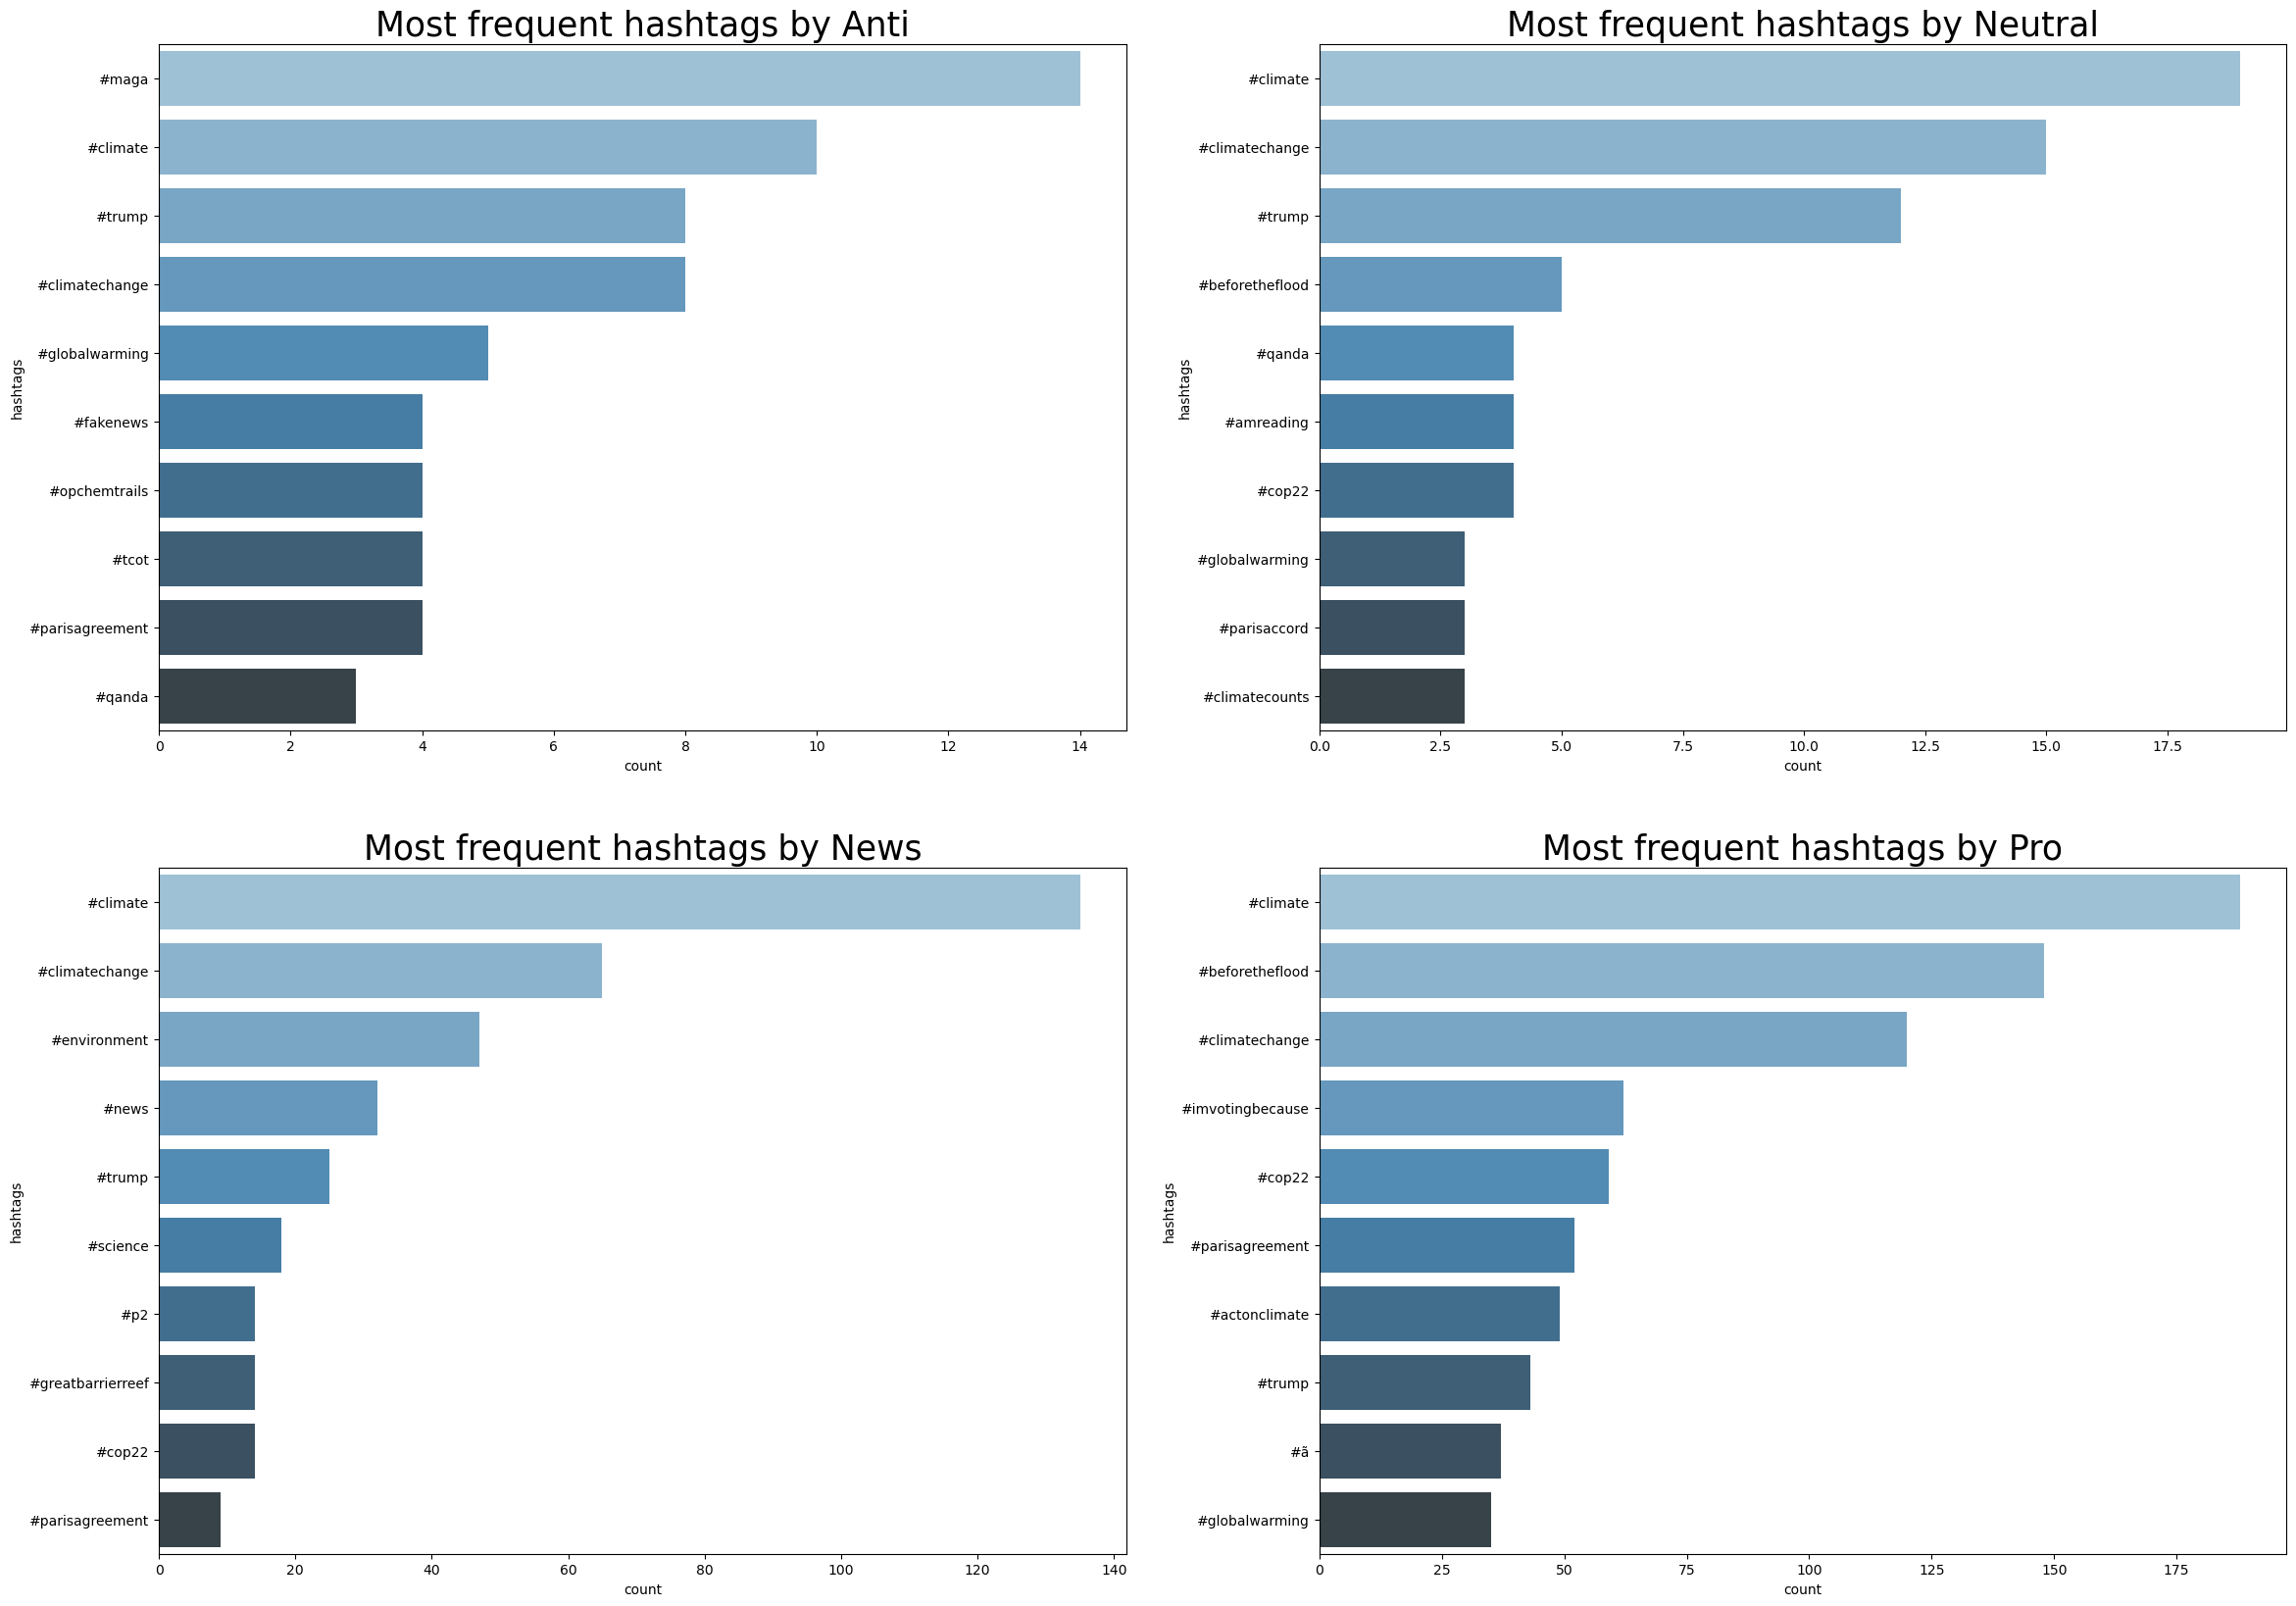

In [102]:
#Visuals of top 10 tweets
fig, axes = plt.subplots(2, 2, figsize=(28, 20))
counter = 0

for sentiment, top in top10.items():
    sns.barplot(data=top, y="hashtags", x="count", palette="Blues_d", ax=axes[counter // 2, counter % 2])
    axes[counter // 2, counter % 2].set_title(f"Most frequent hashtags by {sentiment}", fontsize=25)
    counter += 1
plt.show()

In [103]:
# Creating a column of hastags users
train["users"] = [''.join(re.findall(r'@\w{,}', sentence.lower())) if '@' in sentence else np.nan for sentence in train.message]

In [104]:
# Number of messages per users
users = train[["message", "users"]].groupby("users", as_index = False).count().sort_values(by = "message", ascending = False)
users.head()

,users,message
5876,@stephenschlegel,307
5618,@sensanders,243
5069,@realdonaldtrump,143
736,@berniesanders,121
1430,@cnn,106


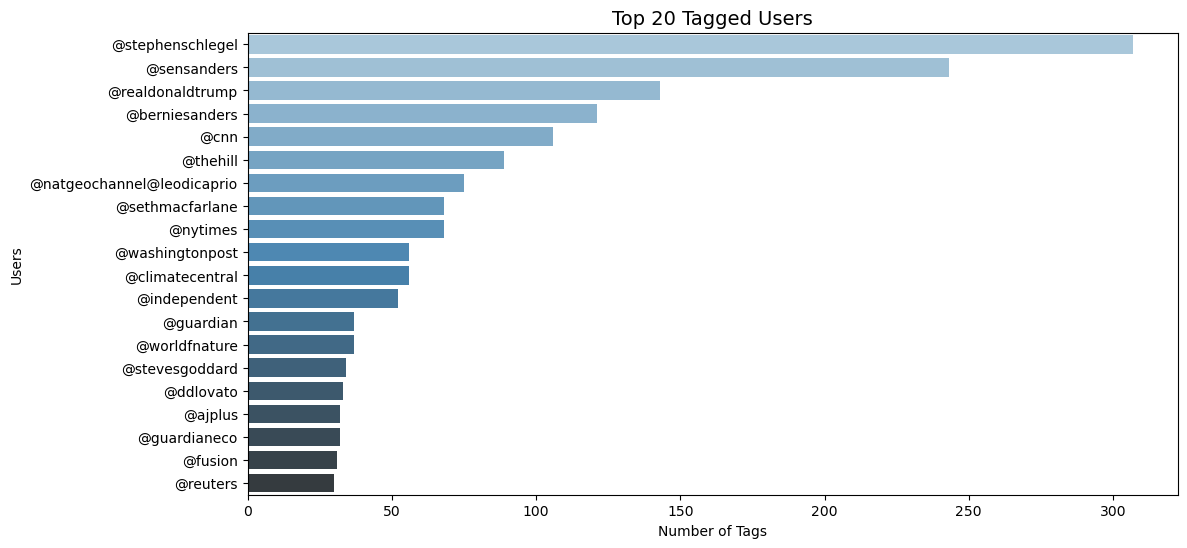

In [105]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data = train, y = "users", order = train.users.value_counts().iloc[:20].index, orient = 'h', palette = "Blues_d")
plt.title("Top 20 Tagged Users", fontsize = 14)
plt.xlabel("Number of Tags")
plt.ylabel("Users")
plt.show()

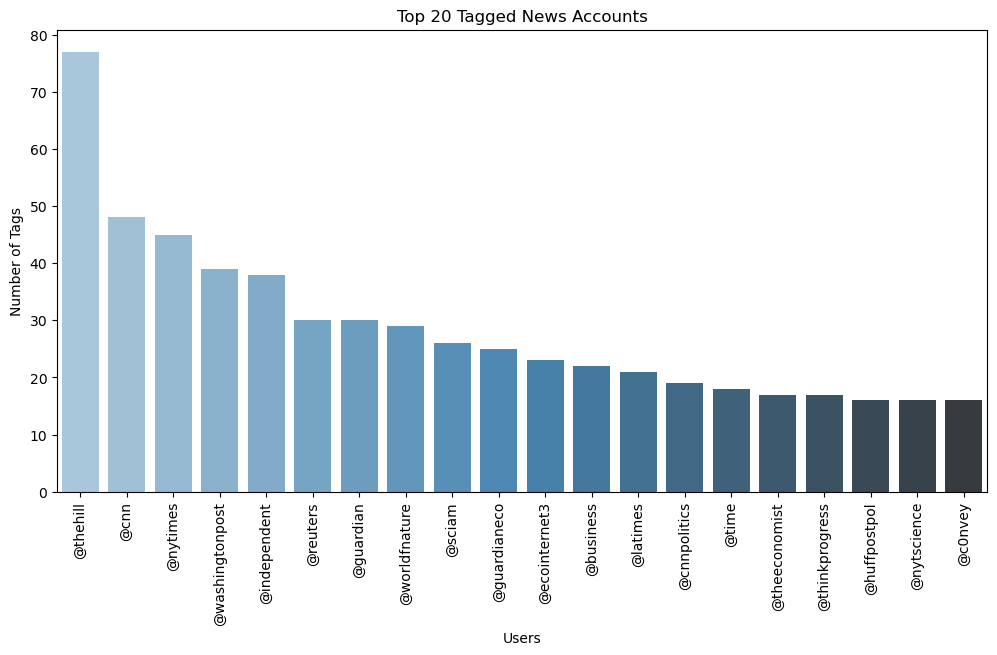

In [106]:
plt.figure(figsize=(12, 6))

sns.countplot(x = "users", data = train[train["sentiment"] == 2], order = train[train["sentiment"] == 2].users.value_counts().iloc[:20].index, palette = "Blues_d") 

plt.xlabel("Users")
plt.ylabel("Number of Tags")
plt.title("Top 20 Tagged News Accounts")
plt.xticks(rotation = 90)
plt.show()

# Base model

In [107]:
lemmatizer = WordNetLemmatizer()
df_train["no_climate"] = df_train["no_climate"].apply(lambda x: [lemmatizer.lemmatize(token) for token in x])
df_test["no_climate"] = df_test["no_climate"].apply(lambda x: [lemmatizer.lemmatize(token) for token in x])
# df_train.head()

In [108]:
X = df_train["no_climate"]
y = df_train["sentiment"]
X_test = df_test["no_climate"]

In [109]:
# Splitting the data into 80% train and 20% validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [110]:
X_train = list(X_train.apply(' '.join))
X_val = list(X_val.apply(' '.join))
X_test = list(X_test.apply(' '.join))

A pipeline is a sequential tool that applies a series of transformations and a final estimator. The intermediate steps of the pipeline utilise fit and transform techniques, while the final estimator only requires fit implementation. Pipelines are helpful for transforming training, validation, and test data, as well as training our models.

Since our models can only process numerical data, our initial task is to construct a pipeline that converts text data into numeric form. In this notebook, we will focus on two feature engineering methods, namely TfidfVectorizer and CountVectorizer, to accomplish this conversion. Subsequently, we will train our models using these pipelines.

By constructing pipelines with both techniques, we will evaluate the average accuracy of the TfidfVectorizer and CountVectorizer. Based on the results, we will decide which feature extraction method, either TF-IDF or CountVectorizer, to utilise for the remaining sections of the notebook.

In [121]:
# Logistic Regression pipeline
logreg_tfidf = Pipeline([("tfidf", TfidfVectorizer()), ("logistic", LogisticRegression()),])
logreg_count = Pipeline([("CountVec",  CountVectorizer()),
                         ("logistic", LogisticRegression()),])

# DecisionTreeClassifier pipeline
tree_tfidf = Pipeline([("tfidf", TfidfVectorizer()), ("tree", DecisionTreeClassifier()),])
tree_count = Pipeline([("CountVec", CountVectorizer()),
                       ("tree", DecisionTreeClassifier()),])

# LinearSVC pipeline
Lsvc_tfidf = Pipeline([("tfidf", TfidfVectorizer()), ("scv", LinearSVC()),])
Lsvc_count = Pipeline([("CountVec", CountVectorizer()),
                       ("svc", LinearSVC()),])

# RandomForestClassifier pipeline
rfc_tfidf = Pipeline([("tfidf", TfidfVectorizer()), ("rfc", RandomForestClassifier())])
rfc_count = Pipeline([("CountVec", CountVectorizer()),
                      ("rfc", RandomForestClassifier()),])

# Ridge model pipeline
ridge_tfidf = Pipeline([("tfidf", TfidfVectorizer()), ("Ridge", RidgeClassifier())])
ridge_count = Pipeline([("CountVec", CountVectorizer()),
                        ("Ridge", RidgeClassifier()),])

# SGD Classifier pipeline
SGD_tfidf = Pipeline([("tfidf", TfidfVectorizer()), ("SGD", SGDClassifier())])
SGD_count = Pipeline([("CountVec", CountVectorizer()),
                      ("SGD", SGDClassifier()),])

# Support Vector Classifier pipeline
svc_tfidf = Pipeline([("tfidf", TfidfVectorizer()), ("SVC", SVC())])
svc_count = Pipeline([("CountVec", CountVectorizer()),
                      ("SVC", SVC()),])

Now we train the models...

In [122]:
# training the logistic regression model
logreg_tfidf.fit(X_train, y_train)
logreg_count.fit(X_train, y_train)

# training the decision tree model
tree_tfidf.fit(X_train, y_train)
tree_count.fit(X_train, y_train)

# training the LinearSVC model
Lsvc_tfidf.fit(X_train, y_train)
Lsvc_count.fit(X_train, y_train)

# training the RandomForest model
rfc_tfidf.fit(X_train, y_train)
rfc_count.fit(X_train, y_train)

# training the Ridge model
ridge_tfidf.fit(X_train, y_train)
ridge_count.fit(X_train, y_train)

# training the SGD model
SGD_tfidf.fit(X_train, y_train)
SGD_count.fit(X_train, y_train)

# training the support vector model
svc_tfidf.fit(X_train, y_train)
svc_count.fit(X_train, y_train)

c:\Users\user\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

Pipeline(steps=[('CountVec', CountVectorizer()), ('SVC', SVC())])

In [129]:
# calculating average scores for TF-IDF
log_acc = accuracy_score(y_val, logreg_tfidf.predict(X_val))
tree_acc =  accuracy_score(y_val, tree_tfidf.predict(X_val))
lsvc_acc = accuracy_score(y_val, Lsvc_tfidf.predict(X_val))
rfc_acc = accuracy_score(y_val, rfc_tfidf.predict(X_val))
ridge_acc = accuracy_score(y_val, ridge_tfidf.predict(X_val))
sgd_acc = accuracy_score(y_val, SGD_tfidf.predict(X_val))
svc_acc = accuracy_score(y_val, svc_tfidf.predict(X_val))

tfidf_avg_accuracy = round(np.mean([log_acc, tree_acc, lsvc_acc, rfc_acc, ridge_acc, sgd_acc, svc_acc]), 4)

In [124]:
# calculating average scores for CountVec
log_acc = accuracy_score(y_val, logreg_count.predict(X_val))
tree_acc =  accuracy_score(y_val, tree_count.predict(X_val))
lsvc_acc = accuracy_score(y_val, Lsvc_count.predict(X_val))
rfc_acc = accuracy_score(y_val, rfc_count.predict(X_val))
ridge_acc = accuracy_score(y_val, ridge_count.predict(X_val))
sgd_acc = accuracy_score(y_val, SGD_count.predict(X_val))
svc_acc = accuracy_score(y_val, svc_count.predict(X_val))

count_avg_accuracy = round(np.mean([log_acc, tree_acc, lsvc_acc, rfc_acc, ridge_acc, sgd_acc, svc_acc]), 4)

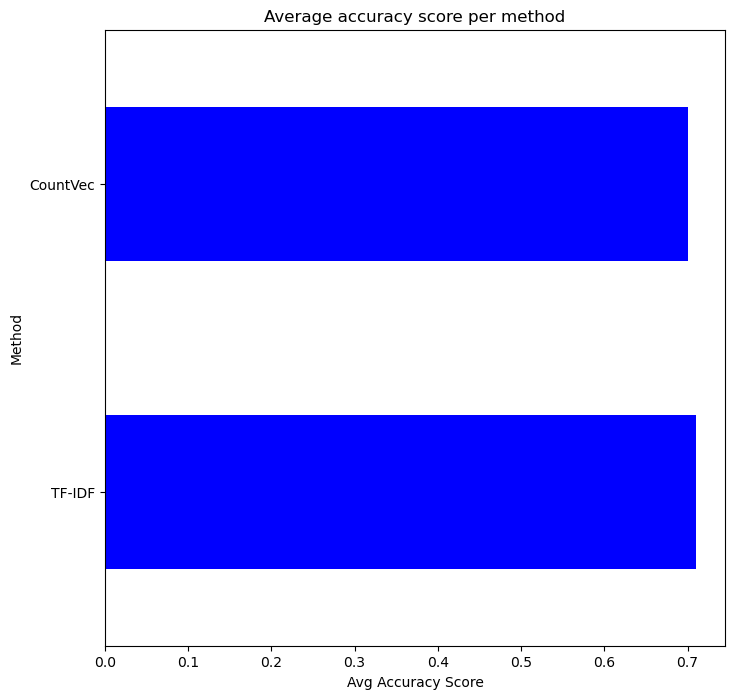

In [125]:
accuracy_dict = {'TF-IDF':[tfidf_avg_accuracy], 'CountVec':[count_avg_accuracy]}
accuracy_df = pd.DataFrame(accuracy_dict)
accuracy_df.T.plot(kind='barh', figsize = (8,8),legend = False, color = 'blue')
plt.xlabel('Avg Accuracy Score')
plt.ylabel('Method')
plt.title('Average accuracy score per method')
# plt.grid()
plt.show()

In [128]:
accuracy_dict

{'TF-IDF': [0.7096], 'CountVec': [0.7002]}

In [133]:
logreg_prediction = logreg_tfidf.predict(X_val) # Logistic regression predictions



Logistic Regression
 [[  88   32  152    6]
 [  10  156  238   21]
 [   9   55 1564  127]
 [   4   12  208  482]]



Logistic Regression
               precision    recall  f1-score   support

          -1       0.79      0.32      0.45       278
           0       0.61      0.37      0.46       425
           1       0.72      0.89      0.80      1755
           2       0.76      0.68      0.72       706

    accuracy                           0.72      3164
   macro avg       0.72      0.56      0.61      3164
weighted avg       0.72      0.72      0.70      3164



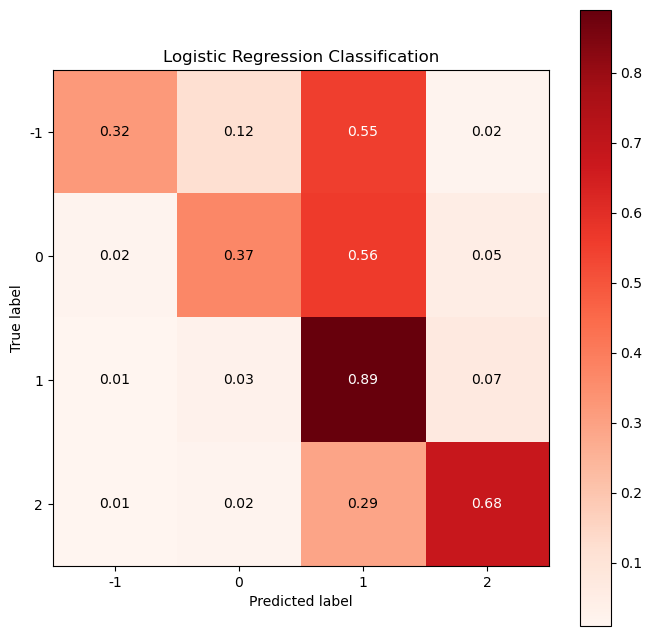

In [134]:
# Report the confusion matrix
print('\nLogistic Regression\n', confusion_matrix(y_val, logreg_prediction))
print()
print()
# Print a classification report
print('\nLogistic Regression\n', classification_report(y_val, logreg_prediction))
plot_confusion_matrix(y_val, logreg_prediction, normalize=True,figsize=(8,8),cmap='Reds')
plt.title('Logistic Regression Classification')
plt.show()

In [234]:
y_pred = logreg_count.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 0, 1], dtype=int64)

In [235]:
test["sentiment"] = y_pred

In [236]:
test[['tweetid','sentiment']]

,tweetid,sentiment
0,169760,1
1,35326,1
2,224985,1
3,476263,1
4,872928,0
...,...,...
10541,895714,1
10542,875167,1
10543,78329,1
10544,867455,0


In [237]:
test[['tweetid','sentiment']].to_csv("base_model.csv", index = False)